**Cell 1 — Imports & Setup**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from einops import rearrange, repeat

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cpu
GPU available: False


**Cell 2 — Scaled Dot-Product Attention (From Scratch)**

In [2]:
class ScaledDotProductAttention(nn.Module):
    """
    Scaled Dot-Product Attention

    Attention(Q, K, V) = softmax(QK^T / √d_k) V

    Where:
      Q = Query (batch, seq_len, d_k)
      K = Key   (batch, seq_len, d_k)
      V = Value (batch, seq_len, d_v)
    """

    def __init__(self, d_k, dropout=0.0):
        super().__init__()
        self.d_k = d_k
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q: (batch, seq_len, d_k)
            K: (batch, seq_len, d_k)
            V: (batch, seq_len, d_v)
            mask: (batch, 1, seq_len, seq_len) or None

        Returns:
            output: (batch, seq_len, d_v)
            attention_weights: (batch, seq_len, seq_len)
        """

        # Step 1: Compute similarity scores (QK^T)
        scores = torch.matmul(Q, K.transpose(-2, -1))
        # scores shape: (batch, seq_len, seq_len)

        # Step 2: Scale by √d_k
        scores = scores / np.sqrt(self.d_k)
        # Prevents dot products from getting too large

        # Step 3: Apply mask (if provided)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            # Set masked positions to large negative (softmax → 0)

        # Step 4: Apply softmax to get attention weights
        attention_weights = torch.softmax(scores, dim=-1)
        # attention_weights shape: (batch, seq_len, seq_len)
        # Each row sums to 1 (probability distribution)

        # Step 5: Apply dropout
        attention_weights = self.dropout(attention_weights)

        # Step 6: Apply to values (weighted sum)
        output = torch.matmul(attention_weights, V)
        # output shape: (batch, seq_len, d_v)

        return output, attention_weights

# Test it out
print("=" * 70)
print("SCALED DOT-PRODUCT ATTENTION")
print("=" * 70)

# Create dummy data
batch_size = 2
seq_len = 4
d_k = 64
d_v = 64

Q = torch.randn(batch_size, seq_len, d_k)  # Query
K = torch.randn(batch_size, seq_len, d_k)  # Key
V = torch.randn(batch_size, seq_len, d_v)  # Value

# Create attention layer
attention = ScaledDotProductAttention(d_k=d_k, dropout=0.0)

# Forward pass
output, weights = attention(Q, K, V)

print(f"\nInput shapes:")
print(f"  Q: {Q.shape}")
print(f"  K: {K.shape}")
print(f"  V: {V.shape}")

print(f"\nOutput shapes:")
print(f"  output: {output.shape}")
print(f"  attention_weights: {weights.shape}")

print(f"\nAttention weights (first batch, first query):")
print(weights[0, 0])  # Should sum to 1
print(f"Sum: {weights[0, 0].sum().item():.4f}")  # Should be 1.0

SCALED DOT-PRODUCT ATTENTION

Input shapes:
  Q: torch.Size([2, 4, 64])
  K: torch.Size([2, 4, 64])
  V: torch.Size([2, 4, 64])

Output shapes:
  output: torch.Size([2, 4, 64])
  attention_weights: torch.Size([2, 4, 4])

Attention weights (first batch, first query):
tensor([0.1056, 0.3017, 0.1507, 0.4419])
Sum: 1.0000


**Cell 3 — Visualise Attention Weights**

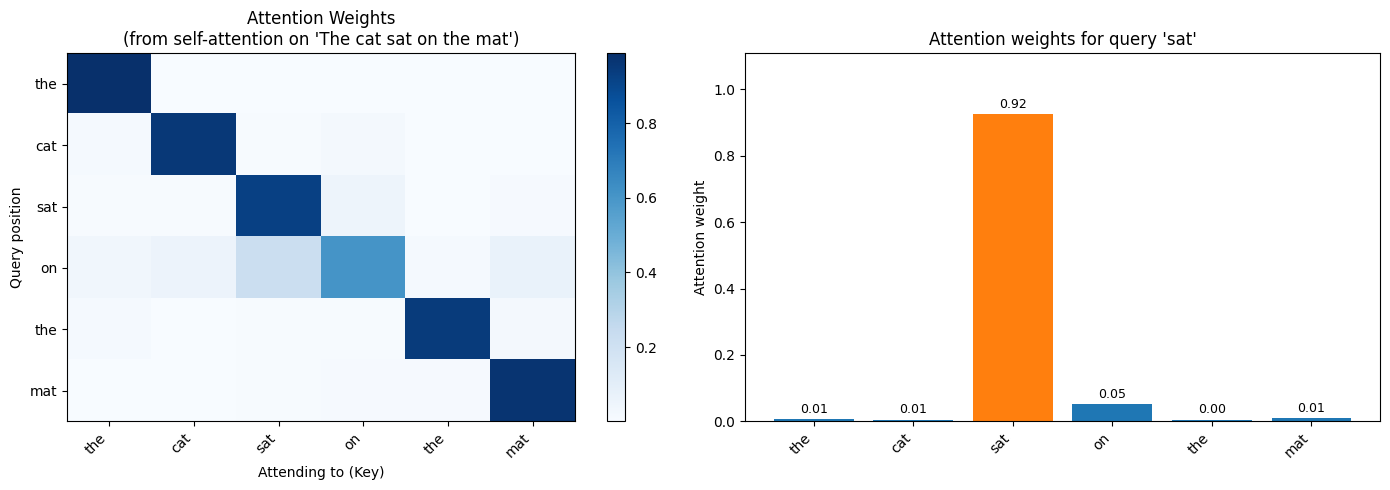

Attention distribution for 'sat':
  the   : 0.006 
  cat   : 0.005 
  sat   : 0.924 ██████████████████████████████████████████████
  on    : 0.051 ██
  the   : 0.005 
  mat   : 0.009 


In [3]:
# Create a simple example: "The cat sat on the mat"
vocab = ["the", "cat", "sat", "on", "the", "mat"]
seq_len = len(vocab)

# Create learnable embeddings for this sequence
embed_dim = 32
embeddings = nn.Embedding(seq_len, embed_dim)
indices = torch.arange(seq_len)
x = embeddings(indices).unsqueeze(0)  # Add batch dimension: (1, 6, 32)

# Create Q, K, V (for simplicity, same as input)
Q = K = V = x
d_k = embed_dim

# Compute attention
attention = ScaledDotProductAttention(d_k=d_k, dropout=0.0)
output, weights = attention(Q, K, V)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of attention weights
ax = axes[0]
im = ax.imshow(weights[0].detach().numpy(), cmap='Blues', aspect='auto')
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(vocab, rotation=45, ha='right')
ax.set_yticklabels(vocab)
ax.set_xlabel("Attending to (Key)")
ax.set_ylabel("Query position")
ax.set_title("Attention Weights\n(from self-attention on 'The cat sat on the mat')")
plt.colorbar(im, ax=ax)

# Show attention for one query position
query_pos = 2  # "sat"
ax = axes[1]
attn_for_pos = weights[0, query_pos].detach().numpy()
bars = ax.bar(range(seq_len), attn_for_pos, color=['#1f77b4' if i != query_pos else '#ff7f0e' for i in range(seq_len)])
ax.set_xticks(range(seq_len))
ax.set_xticklabels(vocab, rotation=45, ha='right')
ax.set_ylabel("Attention weight")
ax.set_title(f"Attention weights for query '{vocab[query_pos]}'")
ax.set_ylim(0, max(attn_for_pos) * 1.2)

# Add value labels on bars
for i, v in enumerate(attn_for_pos):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Attention distribution for '{vocab[query_pos]}':")
for i, (token, weight) in enumerate(zip(vocab, attn_for_pos)):
    bar = '█' * int(weight * 50)
    print(f"  {token:6s}: {weight:.3f} {bar}")

**Cell 4 — Multi-Head Attention (From Scratch)**

In [4]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention

    Allows the model to attend to different representation subspaces.

    MultiHeadAttention(Q, K, V) = Concat(head_1, ..., head_h) W^O

    Where:
      head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)
    """

    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension of each head
        self.d_v = d_model // num_heads

        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Output projection
        self.W_o = nn.Linear(d_model, d_model)

        # Attention mechanism
        self.attention = ScaledDotProductAttention(d_k=self.d_k, dropout=dropout)

        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q: (batch, seq_len, d_model)
            K: (batch, seq_len, d_model)
            V: (batch, seq_len, d_model)
            mask: (batch, 1, seq_len, seq_len) or None

        Returns:
            output: (batch, seq_len, d_model)
            attention_weights: (batch, num_heads, seq_len, seq_len)
        """
        batch_size = Q.shape[0]

        # Step 1: Linear projections
        Q = self.W_q(Q)  # (batch, seq_len, d_model)
        K = self.W_k(K)
        V = self.W_v(V)

        # Step 2: Reshape for multi-head
        # Split d_model into num_heads
        Q = rearrange(Q, 'b seq (h d) -> b h seq d', h=self.num_heads)
        K = rearrange(K, 'b seq (h d) -> b h seq d', h=self.num_heads)
        V = rearrange(V, 'b seq (h d) -> b h seq d', h=self.num_heads)
        # Q shape: (batch, num_heads, seq_len, d_k)

        # Step 3: Apply attention for each head
        # (We apply attention to all heads at once due to batching)
        Q_flat = rearrange(Q, 'b h seq d -> (b h) seq d')
        K_flat = rearrange(K, 'b h seq d -> (b h) seq d')
        V_flat = rearrange(V, 'b h seq d -> (b h) seq d')

        if mask is not None:
            mask = repeat(mask, 'b 1 s1 s2 -> (b h) 1 s1 s2', h=self.num_heads)

        attn_output, attn_weights = self.attention(Q_flat, K_flat, V_flat, mask)
        # attn_output: ((batch*num_heads), seq_len, d_v)

        # Step 4: Reshape back
        attn_output = rearrange(attn_output, '(b h) seq d -> b seq (h d)',
                                b=batch_size, h=self.num_heads)
        attn_weights = rearrange(attn_weights, '(b h) seq1 seq2 -> b h seq1 seq2',
                                 b=batch_size, h=self.num_heads)
        # attn_output: (batch, seq_len, d_model)

        # Step 5: Output projection
        output = self.W_o(attn_output)

        return output, attn_weights

# Test multi-head attention
print("=" * 70)
print("MULTI-HEAD ATTENTION")
print("=" * 70)

batch_size = 2
seq_len = 6
d_model = 64
num_heads = 4

Q = torch.randn(batch_size, seq_len, d_model)
K = torch.randn(batch_size, seq_len, d_model)
V = torch.randn(batch_size, seq_len, d_model)

mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=0.0)
output, weights = mha(Q, K, V)

print(f"\nInput shapes:")
print(f"  Q: {Q.shape}")
print(f"  K: {K.shape}")
print(f"  V: {V.shape}")

print(f"\nOutput shapes:")
print(f"  output: {output.shape}")
print(f"  attention_weights: {weights.shape}")

print(f"\nAttention breakdown:")
print(f"  d_model: {d_model}")
print(f"  num_heads: {num_heads}")
print(f"  d_k per head: {d_model // num_heads}")
print(f"  Each head operates on {d_model // num_heads} dimensions")
print(f"  All heads concatenated: {num_heads} * {d_model // num_heads} = {d_model}")

MULTI-HEAD ATTENTION

Input shapes:
  Q: torch.Size([2, 6, 64])
  K: torch.Size([2, 6, 64])
  V: torch.Size([2, 6, 64])

Output shapes:
  output: torch.Size([2, 6, 64])
  attention_weights: torch.Size([2, 4, 6, 6])

Attention breakdown:
  d_model: 64
  num_heads: 4
  d_k per head: 16
  Each head operates on 16 dimensions
  All heads concatenated: 4 * 16 = 64


**Cell 5 — Positional Encoding (From Scratch)**

POSITIONAL ENCODING


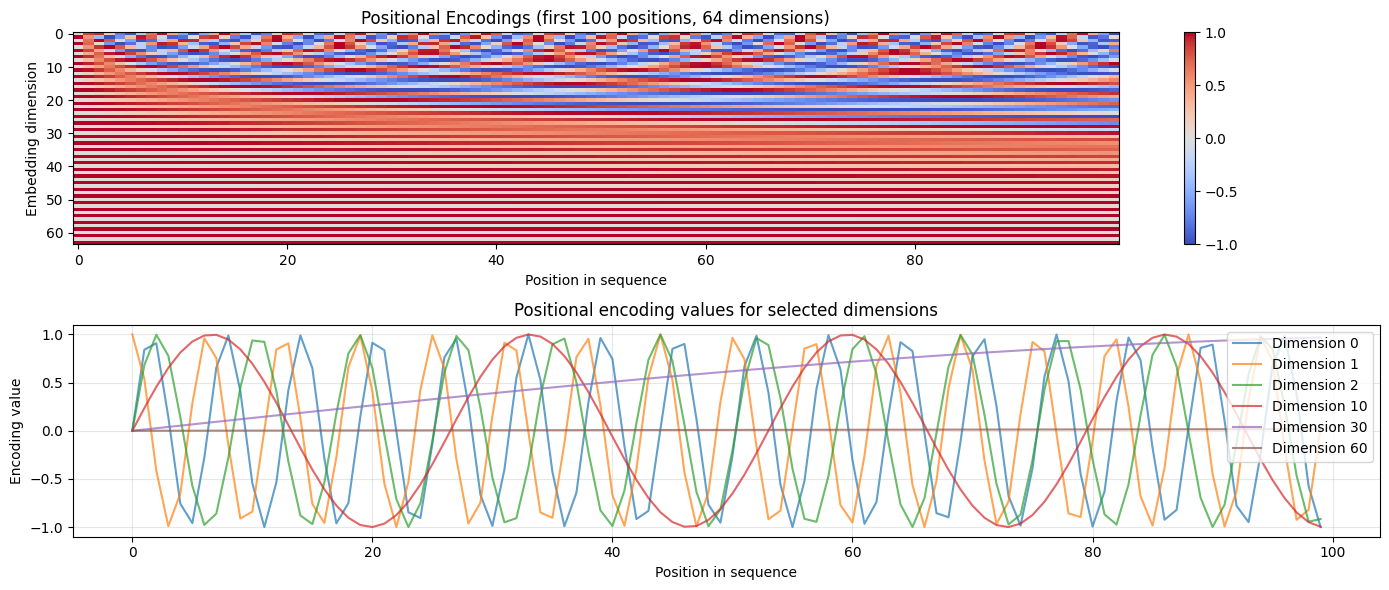


Positional encoding shape: torch.Size([1, 512, 64])
Encoding range: [-1.000, 1.000]

Observations:
  - Low frequency dimensions (left) change slowly across positions
  - High frequency dimensions (right) oscillate rapidly
  - Each position has a unique encoding
  - Bounded between -1 and 1 (numerically stable)


In [5]:
class PositionalEncoding(nn.Module):
    """
    Positional Encoding using sinusoidal functions

    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """

    def __init__(self, d_model, max_seq_len=512, dropout=0.0):
        super().__init__()
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)

        # Precompute positional encodings
        pe = torch.zeros(max_seq_len, d_model)

        pos = torch.arange(0, max_seq_len).unsqueeze(1).float()  # (max_seq_len, 1)

        # Compute the angle rates
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             -(np.log(10000.0) / d_model))
        # div_term shape: (d_model // 2,)

        # Apply sin to even indices
        pe[:, 0::2] = torch.sin(pos * div_term)

        # Apply cos to odd indices
        pe[:, 1::2] = torch.cos(pos * div_term)

        # Register as buffer (not a parameter, but saved with model)
        self.register_buffer('pe', pe.unsqueeze(0))
        # pe shape: (1, max_seq_len, d_model)

    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)

        Returns:
            x + positional encoding: (batch, seq_len, d_model)
        """
        seq_len = x.shape[1]
        return x + self.pe[:, :seq_len, :]

# Test positional encoding
print("=" * 70)
print("POSITIONAL ENCODING")
print("=" * 70)

d_model = 64
max_seq_len = 512

pos_enc = PositionalEncoding(d_model=d_model, max_seq_len=max_seq_len)

# Visualise
pe_matrix = pos_enc.pe[0, :100, :].detach().numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Heatmap
ax = axes[0]
im = ax.imshow(pe_matrix.T, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Embedding dimension")
ax.set_title("Positional Encodings (first 100 positions, 64 dimensions)")
plt.colorbar(im, ax=ax)

# Line plot: show a few dimensions
ax = axes[1]
for dim in [0, 1, 2, 10, 30, 60]:
    ax.plot(pe_matrix[:, dim], label=f"Dimension {dim}", alpha=0.7)
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Encoding value")
ax.set_title("Positional encoding values for selected dimensions")
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPositional encoding shape: {pos_enc.pe.shape}")
print(f"Encoding range: [{pe_matrix.min():.3f}, {pe_matrix.max():.3f}]")
print("\nObservations:")
print("  - Low frequency dimensions (left) change slowly across positions")
print("  - High frequency dimensions (right) oscillate rapidly")
print("  - Each position has a unique encoding")
print("  - Bounded between -1 and 1 (numerically stable)")

**Cell 6 — Feed-Forward Network (From Scratch)**

In [6]:
class PositionWiseFeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network

    FFN(x) = max(0, xW_1 + b_1)W_2 + b_2

    Applied independently to each position.
    Typically, d_ff = 4 * d_model
    """

    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()

    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)

        Returns:
            output: (batch, seq_len, d_model)
        """
        return self.linear2(self.dropout(self.activation(self.linear1(x))))

# Test feed-forward
print("=" * 70)
print("POSITION-WISE FEED-FORWARD")
print("=" * 70)

d_model = 64
d_ff = 256  # 4x d_model

ffn = PositionWiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=0.1)

x = torch.randn(2, 6, d_model)
output = ffn(x)

print(f"\nInput shape: {x.shape}")
print(f"Output shape: {output.shape}")

# Count parameters
total_params = sum(p.numel() for p in ffn.parameters())
print(f"\nTotal parameters in FFN: {total_params:,}")
print(f"  Layer 1: {d_model} → {d_ff} = {d_model * d_ff:,} weights + {d_ff} biases")
print(f"  Layer 2: {d_ff} → {d_model} = {d_ff * d_model:,} weights + {d_model} biases")

POSITION-WISE FEED-FORWARD

Input shape: torch.Size([2, 6, 64])
Output shape: torch.Size([2, 6, 64])

Total parameters in FFN: 33,088
  Layer 1: 64 → 256 = 16,384 weights + 256 biases
  Layer 2: 256 → 64 = 16,384 weights + 64 biases


**Cell 7 — Full Transformer Block (From Scratch)**

In [8]:
class TransformerBlock(nn.Module):
    """
    Single Transformer encoder block

    1. Multi-head self-attention
    2. Residual connection + layer norm
    3. Position-wise feed-forward
    4. Residual connection + layer norm
    """

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # Multi-head attention
        self.mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)

        # Feed-forward network
        self.ffn = PositionWiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)

        # Layer normalisations
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Args:
            x: (batch, seq_len, d_model)
            mask: (batch, 1, seq_len, seq_len) or None

        Returns:
            output: (batch, seq_len, d_model)
            attn_weights: (batch, num_heads, seq_len, seq_len)
        """

        # Attention block
        x_norm = self.norm1(x)
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, mask)
        x = x + self.dropout(attn_out)  # Residual connection

        # Feed-forward block
        x_norm = self.norm2(x)
        ffn_out = self.ffn(x_norm)
        x = x + self.dropout(ffn_out)  # Residual connection

        return x, attn_weights

# Test Transformer block
print("=" * 70)
print("TRANSFORMER ENCODER BLOCK")
print("=" * 70)

d_model = 64
num_heads = 4
d_ff = 256
batch_size = 2
seq_len = 6

block = TransformerBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff, dropout=0.1)

x = torch.randn(batch_size, seq_len, d_model)
output, attn_weights = block(x)

print(f"\nInput shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

# Count parameters
total_params = sum(p.numel() for p in block.parameters())
print(f"\nTotal parameters in block: {total_params:,}")

print(f"\nBlock composition:")
print(f"  - Multi-head attention: {d_model}×{d_model} input")
print(f"  - {num_heads} heads of {d_model // num_heads} dimensions each")
print(f"  - Feed-forward: {d_model} → {d_ff} → {d_model}")
print(f"  - Residual connections + layer normalization")

TRANSFORMER ENCODER BLOCK

Input shape: torch.Size([2, 6, 64])
Output shape: torch.Size([2, 6, 64])
Attention weights shape: torch.Size([2, 4, 6, 6])

Total parameters in block: 49,984

Block composition:
  - Multi-head attention: 64×64 input
  - 4 heads of 16 dimensions each
  - Feed-forward: 64 → 256 → 64
  - Residual connections + layer normalization


**Cell 8 — Stack Multiple Blocks (Transformer Encoder)**

In [9]:
class TransformerEncoder(nn.Module):
    """
    Stack of Transformer encoder blocks
    """

    def __init__(self, d_model, num_heads, d_ff, num_layers, max_seq_len=512, dropout=0.1):
        super().__init__()

        # Positional encoding
        self.pos_enc = PositionalEncoding(d_model=d_model, max_seq_len=max_seq_len, dropout=dropout)

        # Stack of transformer blocks
        self.layers = nn.ModuleList([
            TransformerBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.d_model = d_model

    def forward(self, x, mask=None):
        """
        Args:
            x: (batch, seq_len, d_model)
            mask: (batch, 1, seq_len, seq_len) or None

        Returns:
            output: (batch, seq_len, d_model)
            all_attn_weights: list of attention weights from each layer
        """

        # Add positional encoding
        x = self.pos_enc(x)

        all_attn_weights = []

        # Pass through all layers
        for layer in self.layers:
            x, attn_weights = layer(x, mask)
            all_attn_weights.append(attn_weights)

        return x, all_attn_weights

# Test full encoder
print("=" * 70)
print("FULL TRANSFORMER ENCODER")
print("=" * 70)

d_model = 64
num_heads = 4
d_ff = 256
num_layers = 2  # Like BERT-tiny
batch_size = 2
seq_len = 6

encoder = TransformerEncoder(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    num_layers=num_layers,
    dropout=0.1
)

x = torch.randn(batch_size, seq_len, d_model)
output, all_attn_weights = encoder(x)

print(f"\nInput shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Number of layers: {num_layers}")
print(f"Attention weights from each layer: {len(all_attn_weights)}")
print(f"Each layer's attention shape: {all_attn_weights[0].shape}")

# Count parameters
total_params = sum(p.numel() for p in encoder.parameters())
print(f"\nTotal parameters in encoder: {total_params:,}")

print(f"\nArchitecture:")
print(f"  Input embedding: {d_model} dimensions")
print(f"  {num_layers} transformer blocks, each with:")
print(f"    - Multi-head attention: {num_heads} heads × {d_model // num_heads} dims")
print(f"    - Feed-forward: {d_model} → {d_ff} → {d_model}")
print(f"    - Residual connections + layer norm")
print(f"  Output: {d_model} dimensions")

FULL TRANSFORMER ENCODER

Input shape: torch.Size([2, 6, 64])
Output shape: torch.Size([2, 6, 64])
Number of layers: 2
Attention weights from each layer: 2
Each layer's attention shape: torch.Size([2, 4, 6, 6])

Total parameters in encoder: 99,968

Architecture:
  Input embedding: 64 dimensions
  2 transformer blocks, each with:
    - Multi-head attention: 4 heads × 16 dims
    - Feed-forward: 64 → 256 → 64
    - Residual connections + layer norm
  Output: 64 dimensions


**Cell 9 — Use Pre-trained BERT (Preview of Phase 3 Part 3)**

In [10]:
print("=" * 70)
print("PREVIEW: BERT FROM HUGGINGFACE")
print("=" * 70)

# Install if needed
# !pip install transformers -q

from transformers import AutoTokenizer, AutoModel

# Load tiny BERT
model_name = "prajjwal1/bert-tiny"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

# Example
text = "The cat sat on the mat"
inputs = tokenizer(text, return_tensors='pt', padding=True)

print(f"\nText: {text}")
print(f"\nTokens: {tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])}")

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

last_hidden_state = outputs.last_hidden_state
all_attentions = outputs.attentions

print(f"\nOutput shapes:")
print(f"  Last hidden state: {last_hidden_state.shape}")
print(f"  Number of attention layers: {len(all_attentions)}")
print(f"  Attention shape per layer: {all_attentions[0].shape}")

print(f"\nBERT-tiny architecture:")
print(f"  - 2 layers (vs 12 in BERT-base)")
print(f"  - 2 attention heads")
print(f"  - 128 hidden dimensions")
print(f"  - Pre-trained on masked language modelling")

print(f"\nNext: You'll fine-tune this on sentiment data!")

PREVIEW: BERT FROM HUGGINGFACE


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertModel LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Text: The cat sat on the mat

Tokens: ['[CLS]', '[UNK]', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']

Output shapes:
  Last hidden state: torch.Size([1, 8, 128])
  Number of attention layers: 2
  Attention shape per layer: torch.Size([1, 2, 8, 8])

BERT-tiny architecture:
  - 2 layers (vs 12 in BERT-base)
  - 2 attention heads
  - 128 hidden dimensions
  - Pre-trained on masked language modelling

Next: You'll fine-tune this on sentiment data!


**Cell 10 — Summary**

In [11]:
print("""
PHASE 3 PART 1 — ATTENTION FROM SCRATCH

✅ Built:
  1. Scaled dot-product attention
     - Query × Key^T
     - Scale by √d_k
     - Softmax for attention weights
     - Weighted sum of values

  2. Multi-head attention
     - Project Q, K, V to multiple heads
     - Compute attention for each head in parallel
     - Concatenate and project output

  3. Positional encoding
     - Sinusoidal functions (sin/cos)
     - Different frequencies for different ranges
     - Makes positions distinguishable

  4. Feed-forward network
     - Expand: d_model → 4*d_model
     - ReLU non-linearity
     - Contract: 4*d_model → d_model

  5. Transformer block
     - Attention + residual + layer norm
     - FFN + residual + layer norm
     - All positions process in parallel

  6. Full encoder stack
     - Positional encoding
     - Multiple transformer blocks
     - Pre-computed attention weights

✨ Key insights:
  - Attention solves RNN bottleneck (parallel, no vanishing gradients)
  - Multi-head lets model learn different patterns
  - Positional encoding tells position (attention doesn't naturally capture order)
  - Residual connections make deep networks trainable
  - Layer norm stabilises training

📖 Next: Read "Attention Is All You Need" paper
🔨 Then: Implement causal masking for GPT-style models
🤖 Then: Fine-tune BERT on sentiment analysis
""")


PHASE 3 PART 1 — ATTENTION FROM SCRATCH

✅ Built:
  1. Scaled dot-product attention
     - Query × Key^T
     - Scale by √d_k
     - Softmax for attention weights
     - Weighted sum of values

  2. Multi-head attention
     - Project Q, K, V to multiple heads
     - Compute attention for each head in parallel
     - Concatenate and project output

  3. Positional encoding
     - Sinusoidal functions (sin/cos)
     - Different frequencies for different ranges
     - Makes positions distinguishable

  4. Feed-forward network
     - Expand: d_model → 4*d_model
     - ReLU non-linearity
     - Contract: 4*d_model → d_model

  5. Transformer block
     - Attention + residual + layer norm
     - FFN + residual + layer norm
     - All positions process in parallel

  6. Full encoder stack
     - Positional encoding
     - Multiple transformer blocks
     - Pre-computed attention weights

✨ Key insights:
  - Attention solves RNN bottleneck (parallel, no vanishing gradients)
  - Multi-head le